In [1]:
import torch
import numpy as np
from rl4evrp.utils import evaluate_agent

import sys
from pathlib import Path

# Add framework to path
framework_path = Path.cwd()
sys.path.insert(0, str(framework_path))

# Import RL4EVRP framework
import rl4evrp as rl

print("✓ RL4EVRP framework imported successfully")

✓ RL4EVRP framework imported successfully


In [2]:
# Initialize framework with configs
framework = rl.RL4EVRP()

# Read configurations from YAML files
problem_config = framework.read_yaml('problem')
model_config = framework.read_yaml('model')
env_config = framework.read_yaml('env')

print("Problem Configuration:")
framework.config.print_config()

✓ Device: cpu
✓ Output directory: results_xai
Problem Configuration:

[ENV]
device: cuda
output_directory: results_xai
log_level: INFO
save_checkpoints: True
checkpoint_interval: 100
llm:
  enabled: False
  provider: groq
  model: llama3-8b-8192
  api_key: ${GROQ_API_KEY}
  timeout: 30
reward_tuning:
  charger_visit_penalty: 0.05
  early_return_penalty: 0.3
  service_bonus: 0.2
  completion_bonus: 2.0
  battery_violation_penalty: 1.0
diagnostics:
  track_masked_actions: True
  warn_on_violations: False
reproducibility:
  seed: 42
  deterministic: True

[MODEL]
encoder:
  type: gat
  embed_dim: 128
  n_heads: 8
  n_layers: 3
  ff_dim: 256
  dropout: 0.0
  layer_norm: True
decoder:
  type: cross_attention
  embed_dim: 128
  n_heads: 8
value_head:
  hidden_dim: 64
  activation: gelu
training:
  optimizer: adam
  lr: 0.0003
  epsilon: 1e-05
  weight_decay: 0.0
  scheduler: cosine_annealing
  T_max: 800
  eta_min_factor: 0.1
  grad_clip_norm: 1.0
  gamma: 0.99
  entropy_coefficient: 0.01
  


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\dnouicer\anaconda3\envs\evrp_env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_in

In [34]:
# Build model using builder pattern
model_builder = framework.build()

# Create A2C agent (contains encoder + decoder)
model = model_builder.complete_model()

print(f"Model device: {model.device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

✓ Agent initialized with 487553 parameters
Model device: cpu
Total parameters: 487,553


In [35]:
import numpy as np

# Generate training and evaluation instances
instance_cfg = problem_config['instance_generation']
n_train = instance_cfg.get('train_size', instance_cfg.get('n_train_instances', 50000))
n_eval = instance_cfg.get('eval_size', instance_cfg.get('n_eval_instances', 100))
seed_offset = instance_cfg.get('seed_offset', 0)

train_instances = [
    framework.generate_instance(seed=seed_offset + i)
    for i in range(n_train)
]

eval_instances = [
    framework.generate_instance(seed=1000 + seed_offset + i)
    for i in range(n_eval)
]

print(f"✓ Generated {len(train_instances)} training instances")
print(f"✓ Generated {len(eval_instances)} evaluation instances")

# Example instance
demo_inst = train_instances[0]
print(f"\nExample instance:")
print(f"  Nodes: {demo_inst['n_nodes']}")
print(f"  Chargers: {(demo_inst['node_types'] == 2).sum()}")
print(f"  Customers: {(demo_inst['node_types'] == 1).sum()}")

✓ Generated 50000 training instances
✓ Generated 100 evaluation instances

Example instance:
  Nodes: 21
  Chargers: 5
  Customers: 15


In [8]:
# Load the trained model
model = model_builder.complete_model()
model.load_state_dict(torch.load('agent_episode_100000.pt', map_location=framework.device))
model.eval()


✓ Agent initialized with 488065 parameters


RuntimeError: Error(s) in loading state_dict for A2CAgent:
	size mismatch for encoder.embed.weight: copying a param with shape torch.Size([128, 7]) from checkpoint, the shape in current model is torch.Size([128, 10]).
	size mismatch for decoder.proj_ctx.weight: copying a param with shape torch.Size([128, 130]) from checkpoint, the shape in current model is torch.Size([128, 131]).

In [37]:

# ============================================
# 1. EVRP evaluation (trained domain)
# ============================================
evrp_stats = evaluate_agent(
    model,
    eval_instances,
    device=str(framework.device),
    greedy=True,
    n_eval=len(eval_instances)  # use all eval instances, not just 20
)
print("EVRP Results:")
print(f"  Distance: {evrp_stats['mean_distance']:.3f} ± {evrp_stats['std_distance']:.3f}")

# ============================================
# 2. Nearest-neighbor baseline (same instances)
# ============================================
from rl4evrp.environment import EVRPEnv  # adjust import to your actual env path

nn_distances = []
for inst in eval_instances:
    env = EVRPEnv(inst, reward_mode='distance')
    env.reset()
    done = False
    while not done:
        vm = env._valid_mask()
        v = np.where(vm)[0]
        _, _, done, info = env.step(v[env.D[env.cur, v].argmin()])
    nn_distances.append(env.total_d)

nn_distances = np.array(nn_distances)
print(f"\nNN Baseline:")
print(f"  Distance: {nn_distances.mean():.3f} ± {nn_distances.std():.3f}")

# ============================================
# 3. Gap
# ============================================
gap = (evrp_stats['mean_distance'] - nn_distances.mean()) / nn_distances.mean() * 100
print(f"\nModel vs NN: {gap:+.1f}%")

# ============================================
# 4. CVRP test (zero-shot transfer)
#    Generate instances WITHOUT chargers and battery
# ============================================
#from rl4evrp.instance import generate_instance  # adjust import

cvrp_instances = []
for i in range(100):
    #inst = generate_instance(20, seed=i + 1000)
    framework.generate_instance(seed=i + 1000)
    # Zero out charger/battery features to make it CVRP
    # Option A: If your generate_instance supports a variant flag:
    # inst = generate_instance(20, seed=i+1000, variant='cvrp')
    
    # Option B: Manually disable EVRP features
    inst['battery_capacity'] = 99999.0  # effectively infinite
    # Remove charger nodes if possible, or set charger_prob=0
    cvrp_instances.append(inst)

cvrp_stats = evaluate_agent(
    model,
    cvrp_instances,
    device=str(framework.device),
    greedy=True,
    n_eval=len(cvrp_instances)
)
print(f"\nCVRP (zero-shot transfer):")
print(f"  Distance: {cvrp_stats['mean_distance']:.3f} ± {cvrp_stats['std_distance']:.3f}")

EVRP Results:
  Distance: 8.066 ± 1.458

NN Baseline:
  Distance: 17.999 ± 10.520

Model vs NN: -55.2%

CVRP (zero-shot transfer):
  Distance: 8.549 ± 0.000


✓ Agent initialized with 487553 parameters


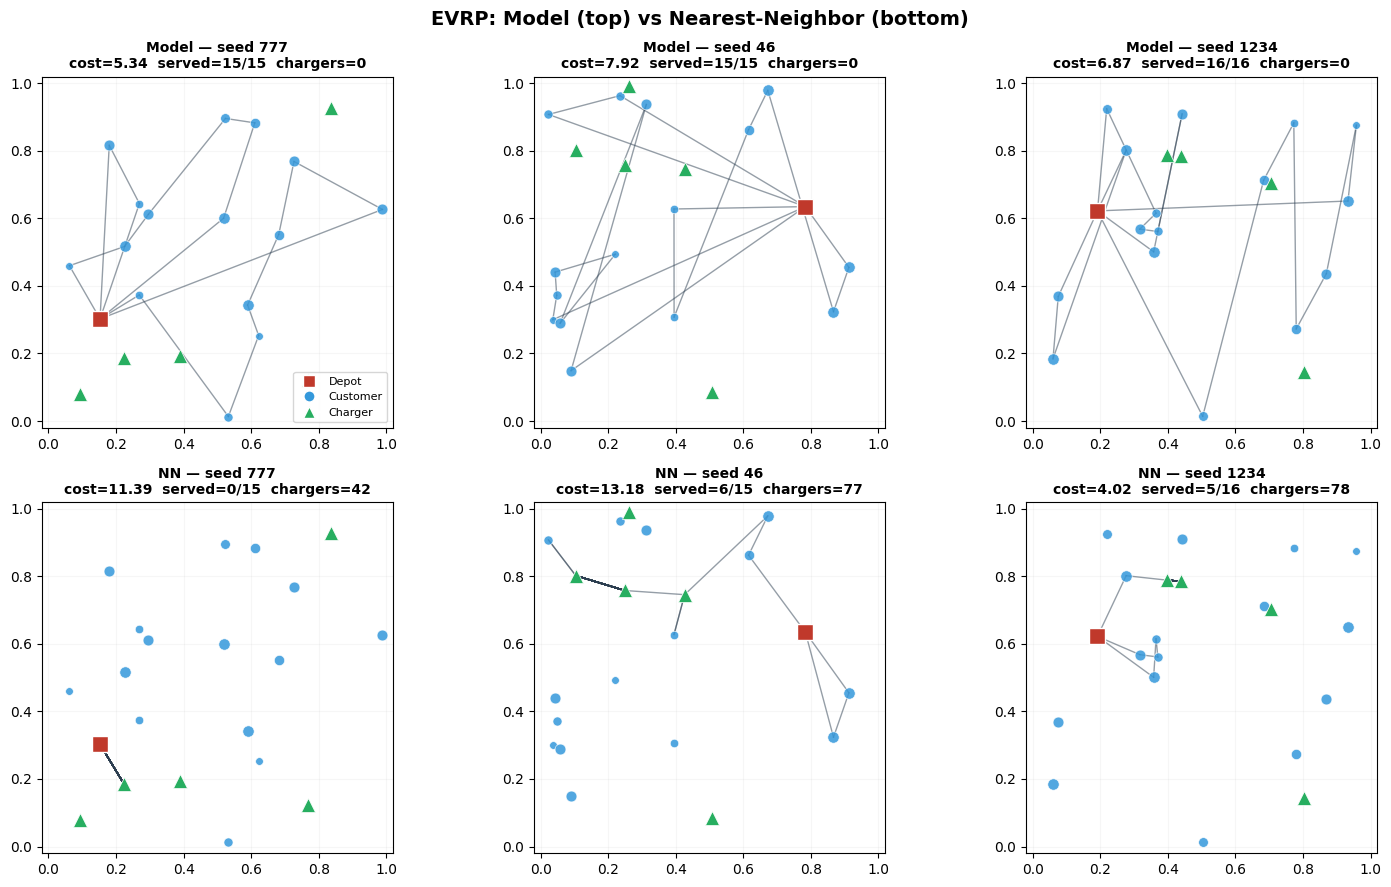

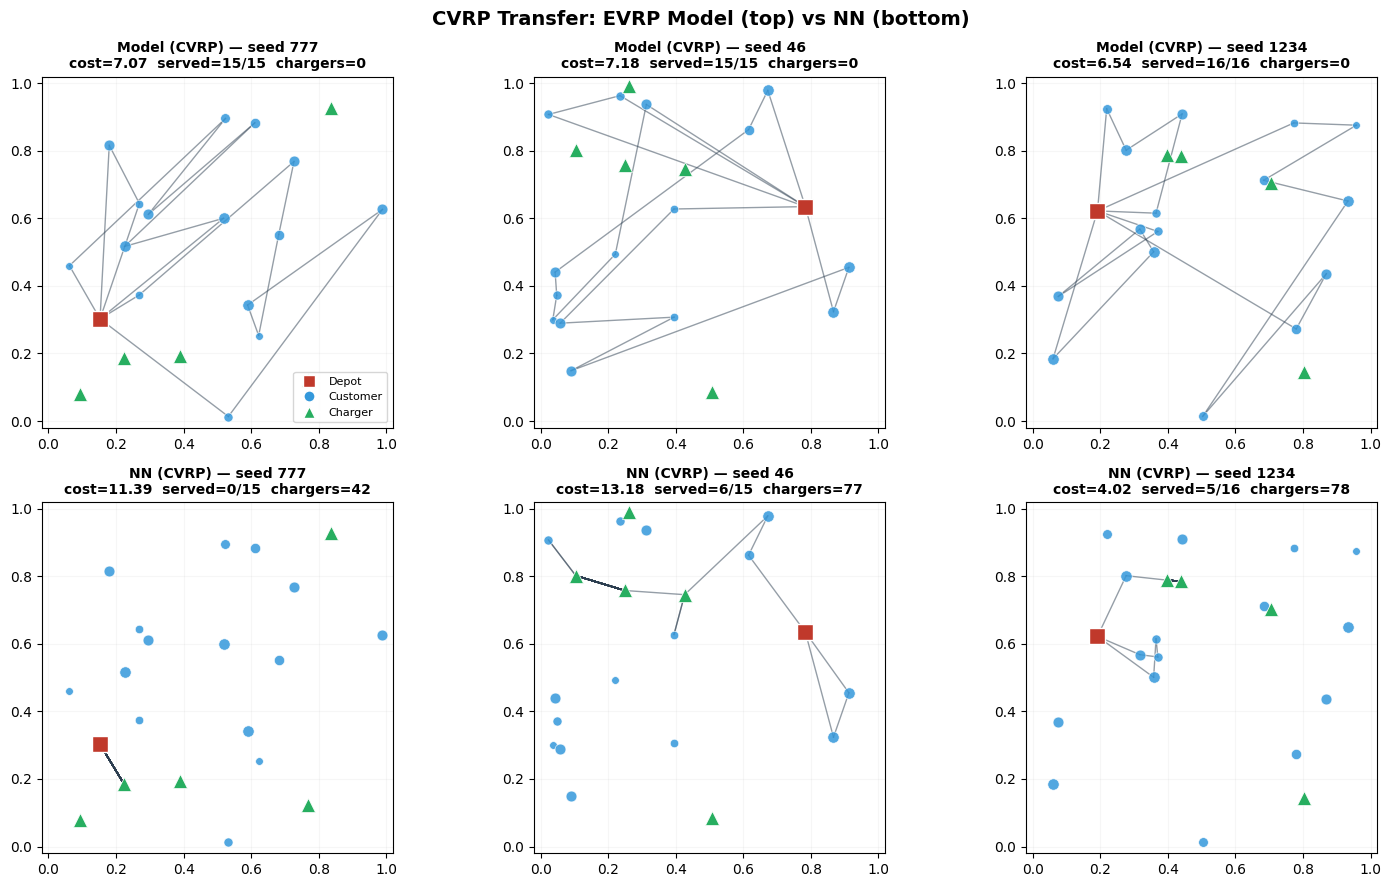

In [42]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from rl4evrp.utils import evaluate_agent
from rl4evrp.environment import EVRPEnv
#from rl4evrp.instance import generate_instance
from rl4evrp.utils import run_episode

# ============================================
# Run model on one instance, return route info
# ============================================

def run_model_episode(agent, instance, device='cpu'):
    inst = dict(instance, reward_mode='distance')
    with torch.no_grad():
        _, _, total_dist, info, _, _, env = run_episode(agent, inst, greedy=True)
    return {
        'route': env.route,
        'total_dist': env.total_d,
        'n_served': info.get('n_customers_served', 0),
        'charger_visits': info.get('charger_visits', 0),
        'battery_log': env.battery_log,
    }

def run_nn_episode(instance):
    inst = dict(instance, reward_mode='distance')
    env = EVRPEnv(inst, reward_mode='distance')
    env.reset()
    done = False
    route = [env.cur]
    battery_log = [env.battery]  # fixed

    while not done:
        vm = env._valid_mask()
        v = np.where(vm)[0]
        action = v[env.D[env.cur, v].argmin()]
        _, _, done, info = env.step(action)
        route.append(action)
        battery_log.append(env.battery)  # fixed

    return {
        'route': route,
        'total_dist': env.total_d,
        'n_served': info.get('n_customers_served', 0),
        'charger_visits': info.get('charger_visits', 0),
        'battery_log': battery_log,
    }


# ============================================
# Plot one route
# ============================================
def plot_route(ax, instance, result, title):
    coords = instance['coords']
    node_types = instance['node_types']
    demands = instance['demands']
    route = result['route']

    # Route lines
    for i in range(len(route) - 1):
        x0, y0 = coords[route[i]]
        x1, y1 = coords[route[i + 1]]
        ax.plot([x0, x1], [y0, y1], color='#2c3e50', linewidth=1.0, alpha=0.5)

    # Nodes
    for i in range(len(coords)):
        x, y = coords[i]
        if node_types[i] == 0:
            ax.plot(x, y, 's', color='#c0392b', markersize=12,
                    markeredgecolor='white', markeredgewidth=1, zorder=5)
        elif node_types[i] == 2:
            ax.plot(x, y, '^', color='#27ae60', markersize=10,
                    markeredgecolor='white', markeredgewidth=0.5, zorder=5)
        else:
            size = 25 + demands[i] * 6
            ax.scatter(x, y, s=size, c='#3498db', zorder=4,
                       edgecolors='white', linewidth=0.5, alpha=0.85)

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')

    n_cust = int((np.array(node_types) == 1).sum())
    ax.set_title(f"{title}\ncost={result['total_dist']:.2f}  "
                 f"served={result['n_served']}/{n_cust}  "
                 f"chargers={result['charger_visits']}", fontsize=10, fontweight='bold')
    ax.grid(alpha=0.1)


# ============================================
# MAIN: Generate 3 instances, compare model vs NN
# ============================================

# Load model
model = model_builder.complete_model()
model.load_state_dict(torch.load('agent_episode_26800.pt', map_location=framework.device))
model.eval()

seeds_to_show = [777,46,1234]
legend_els = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#c0392b', markersize=8, label='Depot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='Customer'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#27ae60', markersize=8, label='Charger'),
]

# --- EVRP ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('EVRP: Model (top) vs Nearest-Neighbor (bottom)', fontsize=14, fontweight='bold')

for col, seed in enumerate(seeds_to_show):
    inst = framework.generate_instance(seed=seed)

    model_result = run_model_episode(model, inst, str(framework.device))
    plot_route(axes[0, col], inst, model_result, f'Model — seed {seed}')

    nn_result = run_nn_episode(inst)
    plot_route(axes[1, col], inst, nn_result, f'NN — seed {seed}')

axes[0, 0].legend(handles=legend_els, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('route_comparison_evrp.pdf', dpi=300, bbox_inches='tight')
plt.show()

# --- CVRP transfer ---
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9))
fig2.suptitle('CVRP Transfer: EVRP Model (top) vs NN (bottom)', fontsize=14, fontweight='bold')

for col, seed in enumerate(seeds_to_show):
    inst = framework.generate_instance(seed=seed)
    inst['battery_cap'] = 99999.0  # disable battery → effectively CVRP

    model_result = run_model_episode(model, inst, str(framework.device))
    plot_route(axes2[0, col], inst, model_result, f'Model (CVRP) — seed {seed}')

    nn_result = run_nn_episode(inst)
    plot_route(axes2[1, col], inst, nn_result, f'NN (CVRP) — seed {seed}')

axes2[0, 0].legend(handles=legend_els, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('route_comparison_cvrp_transfer.pdf', dpi=300, bbox_inches='tight')
plt.show()

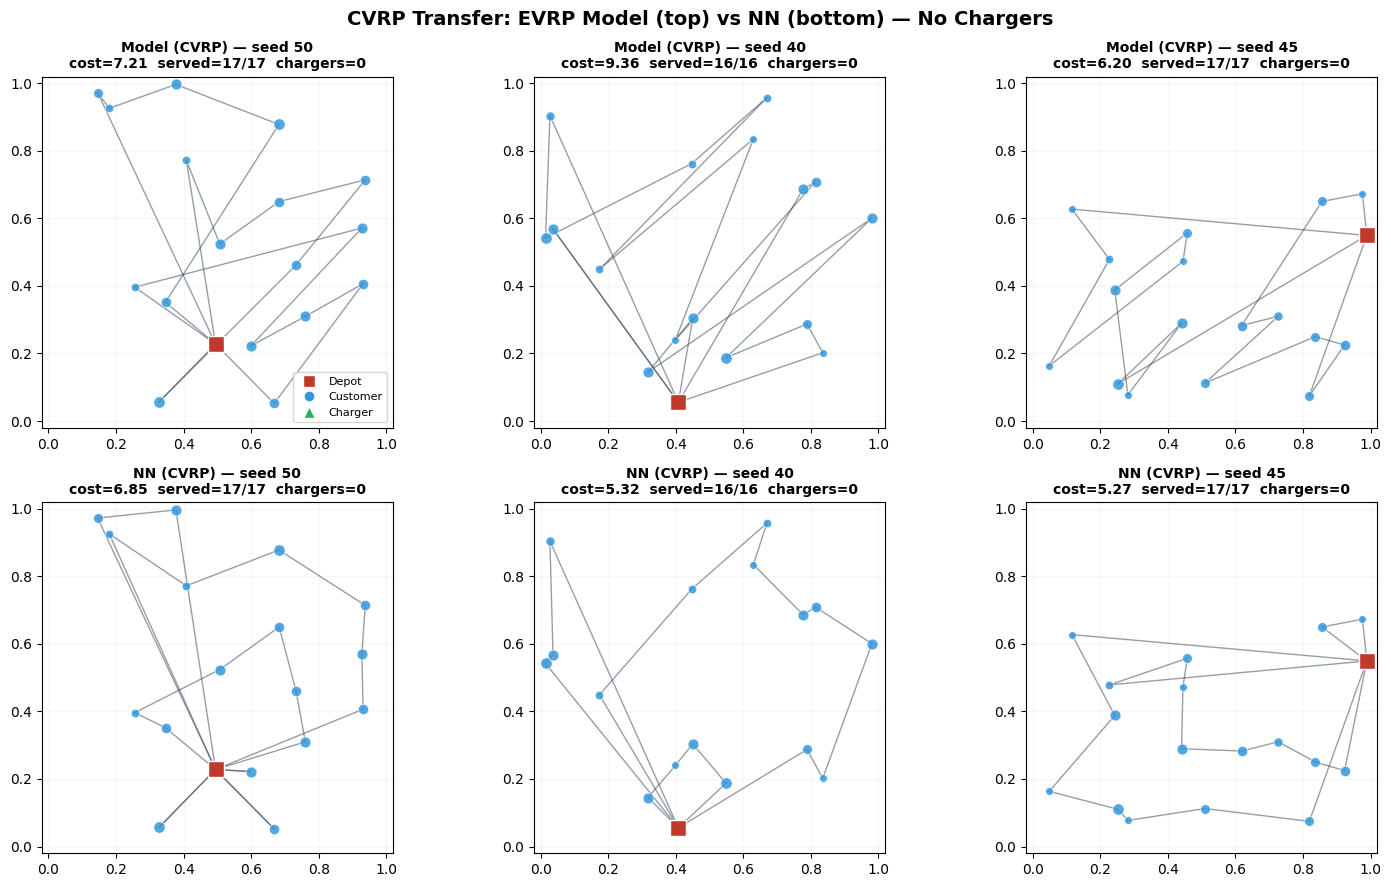

In [39]:
def make_cvrp_instance(evrp_instance):
    """Convert EVRP instance to pure CVRP: remove chargers, disable battery."""
    inst = dict(evrp_instance)
    
    # Find customer and depot nodes only (remove chargers)
    keep = inst['node_types'] != 2  # True for depot and customers
    
    inst['coords'] = inst['coords'][keep]
    inst['demands'] = inst['demands'][keep]
    inst['node_types'] = inst['node_types'][keep]
    inst['n_nodes'] = int(keep.sum())
    inst['battery_cap'] = 99999.0  # effectively infinite
    
    return inst


# --- Plot CVRP transfer ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('CVRP Transfer: EVRP Model (top) vs NN (bottom) — No Chargers',
             fontsize=14, fontweight='bold')

seeds_to_show = [ 50, 40, 45] #500, 501, 502,

for col, seed in enumerate(seeds_to_show):
    evrp_inst = framework.generate_instance(seed=seed)
    cvrp_inst = make_cvrp_instance(evrp_inst)

    model_result = run_model_episode(model, cvrp_inst, str(framework.device))
    plot_route(axes[0, col], cvrp_inst, model_result, f'Model (CVRP) — seed {seed}')

    nn_result = run_nn_episode(cvrp_inst)
    plot_route(axes[1, col], cvrp_inst, nn_result, f'NN (CVRP) — seed {seed}')

axes[0, 0].legend(handles=legend_els, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('route_comparison_cvrp_transfer.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from rl4evrp.environment import EVRPEnv
import importlib
import rl4evrp.environment as env_mod
importlib.reload(env_mod)

# ============================================================
# Run one greedy episode and collect route + battery log
# ============================================================

def run_episode_for_plot(model, instance, device="cpu", greedy=True):
    inst = dict(instance, reward_mode="distance")
    env = EVRPEnv(inst, reward_mode="distance")
    obs = env.reset()

    done = False
    info = {}

    while not done:
        with torch.no_grad():
            action, _, _, _ = model.select_action(obs, greedy=greedy)
        obs, reward, done, info = env.step(action)

    return {
        "route": env.route,
        "battery_log": env.battery_log,
        "total_dist": env.total_d,
        "n_served": info.get("n_customers_served", 0),
        "charger_visits": info.get("charger_visits", 0),
        "all_served": info.get("all_served", False),
        "env": env,
    }


# ============================================================
# Plot route trajectory
# ============================================================

def plot_route_trajectory(ax, instance, result, title="Route trajectory"):
    coords = np.array(instance["coords"])
    node_types = np.array(instance["node_types"])
    demands = np.array(instance["demands"])
    route = result["route"]

    # Draw route edges with arrows
    for i in range(len(route) - 1):
        n1, n2 = route[i], route[i + 1]
        x1, y1 = coords[n1]
        x2, y2 = coords[n2]

        if node_types[n2] == 2:
            edge_color = "#27ae60"   # charger arrival
        elif n2 == 0:
            edge_color = "#c0392b"   # depot arrival
        else:
            edge_color = "#3498db"   # customer arrival

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle="->", color=edge_color, lw=1.8, alpha=0.75)
        )

    # Draw nodes
    for i in range(len(coords)):
        x, y = coords[i]

        if node_types[i] == 0:  # depot
            ax.plot(
                x, y, marker="s", color="#c0392b", markersize=12,
                markeredgecolor="white", markeredgewidth=1.0, zorder=5
            )
            ax.text(x + 0.015, y + 0.015, f"{i}", fontsize=9, fontweight="bold")

        elif node_types[i] == 2:  # charger
            ax.plot(
                x, y, marker="^", color="#27ae60", markersize=10,
                markeredgecolor="white", markeredgewidth=0.7, zorder=5
            )
            ax.text(x + 0.015, y + 0.015, f"{i}", fontsize=8)

        else:  # customer
            size = 30 + demands[i] * 8
            ax.scatter(
                x, y, s=size, c="#3498db",
                edgecolors="white", linewidth=0.6, alpha=0.9, zorder=4
            )
            ax.text(x + 0.015, y + 0.015, f"{i}", fontsize=8)

    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_aspect("equal")
    ax.grid(alpha=0.15)

    ax.set_title(
        f"{title}\n"
        f"dist={result['total_dist']:.2f}, "
        f"served={result['n_served']}, "
        f"chargers={result['charger_visits']}, "
        f"complete={result['all_served']}",
        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# Plot battery over steps
# ============================================================

def plot_battery_over_steps(ax, result, instance, title="Battery state over steps"):
    battery_log = np.array(result["battery_log"], dtype=float)
    route = result["route"]
    battery_cap = float(instance["battery_cap"])

    battery_norm = battery_log / max(battery_cap, 1e-9)
    x = np.arange(len(battery_norm))

    ax.plot(x, battery_norm, marker="o", linewidth=2)

    node_types = np.array(instance["node_types"])
    for step_idx, node in enumerate(route):
        if node_types[node] == 0:
            marker = "s"
            label_color = "#c0392b"
        elif node_types[node] == 2:
            marker = "^"
            label_color = "#27ae60"
        else:
            marker = "o"
            label_color = "#3498db"

        ax.scatter(step_idx, battery_norm[step_idx], marker=marker, s=70, color=label_color, zorder=5)
        ax.text(step_idx, battery_norm[step_idx] + 0.015, str(node), fontsize=8, ha="center")

    ax.axhline(1.0, linestyle="--", linewidth=1, alpha=0.6)
    ax.axhline(0.0, linestyle="--", linewidth=1, alpha=0.6)

    ax.set_xlabel("Step")
    ax.set_ylabel("Battery (normalized)")
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.15)
    ax.set_xlim(-0.3, len(battery_norm) - 0.7)

# ============================================================
# Combined figure
# ============================================================

def plot_route_and_battery(model, framework, seed=777, device=None,
                           greedy=True, save_path="route_battery_example.pdf"):
    if device is None:
        device = str(framework.device)

    instance = framework.generate_instance(seed=seed)
    result = run_episode_for_plot(model, instance, device=device, greedy=greedy)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    plot_route_trajectory(
        axes[0],
        instance,
        result,
        title=f"Example route trajectory (seed={seed})"
    )

    plot_battery_over_steps(
        axes[1],
        result,
        instance,
        title="Battery state over decision steps"
    )

    legend_els = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#c0392b',
               markersize=8, label='Depot'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db',
               markersize=8, label='Customer'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='#27ae60',
               markersize=8, label='Charger'),
    ]
    axes[0].legend(handles=legend_els, fontsize=8, loc='lower right')
    axes[1].legend(handles=legend_els, fontsize=8, loc='best')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure to {save_path}")
    print("Route:", result["route"])
    print("Battery log:", result["battery_log"])

    return instance, result

In [60]:
def load_model(model_path):
    framework = rl.RL4EVRP()
    framework.read_yaml("problem")
    framework.read_yaml("model")
    framework.read_yaml("env")

    model_builder = framework.build()
    model = model_builder.complete_model()

    state_dict = torch.load(model_path, map_location=framework.device)

    print("Checkpoint encoder shape:", state_dict["encoder.embed.weight"].shape)
    print("Current model encoder shape:", model.encoder.embed.weight.shape)

    print("Checkpoint decoder ctx shape:", state_dict["decoder.proj_ctx.weight"].shape)
    print("Current model decoder ctx shape:", model.decoder.proj_ctx.weight.shape)

    model.load_state_dict(state_dict)
    model.to(framework.device)
    model.eval()

    return framework, model

In [36]:
framework = rl.RL4EVRP()
model_builder = framework.build()

model = model_builder.complete_model()
model.load_state_dict(torch.load("agent_evrptw_1k.pt", map_location=framework.device))
model.eval()

instance, result = plot_route_and_battery(
    model=model,
    framework=framework,
    seed=777,
    device=str(framework.device),
    greedy=True,
    save_path="route_battery_example.pdf"
)

✓ Device: cpu
✓ Output directory: results_xai
✓ Agent initialized with 488065 parameters


TypeError: plot_route_and_battery() got an unexpected keyword argument 'model'

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Battery-focused plot for EVRP (no time windows)
# ============================================================

def plot_decision_attribution_evrp(context, df, save_path="decision_attribution_evrp.pdf", top_k=8):
    """
    Plot a compact attribution figure for EVRP without time windows.
    Panels:
      (a) policy probability
      (b) distance
      (c) battery after travel
    """
    df_valid = df[df["valid"] == 1].copy()
    df_valid = df_valid.sort_values("selected_prob", ascending=False).head(top_k).copy()

    def label_row(row):
        nid = int(row["candidate"])
        if row["is_depot"]:
            t = "D"
        elif row["is_charger"]:
            t = "CS"
        else:
            t = "Cust"
        return f"{nid} ({t})"

    df_valid["label"] = df_valid.apply(label_row, axis=1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

    # ---------- Panel 1: policy probability ----------
    bars = axes[0].bar(df_valid["label"], df_valid["selected_prob"])
    for i, (_, row) in enumerate(df_valid.iterrows()):
        if row["selected"] == 1:
            bars[i].set_linewidth(2.0)
            bars[i].set_edgecolor("black")
    axes[0].set_title("(a) Policy preference", loc="left", fontweight="bold")
    axes[0].set_ylabel("Action probability")
    axes[0].tick_params(axis="x", rotation=35)

    # ---------- Panel 2: distance ----------
    bars = axes[1].bar(df_valid["label"], df_valid["distance"])
    for i, (_, row) in enumerate(df_valid.iterrows()):
        if row["selected"] == 1:
            bars[i].set_linewidth(2.0)
            bars[i].set_edgecolor("black")
    axes[1].set_title("(b) Spatial cost", loc="left", fontweight="bold")
    axes[1].set_ylabel("Distance from current node")
    axes[1].tick_params(axis="x", rotation=35)

    # ---------- Panel 3: battery after travel ----------
    bars = axes[2].bar(df_valid["label"], df_valid["battery_after_travel"])
    for i, (_, row) in enumerate(df_valid.iterrows()):
        if row["selected"] == 1:
            bars[i].set_linewidth(2.0)
            bars[i].set_edgecolor("black")
    axes[2].axhline(0, linestyle="--", linewidth=1)
    axes[2].set_title("(c) Energy feasibility", loc="left", fontweight="bold")
    axes[2].set_ylabel("Battery after travel")
    axes[2].tick_params(axis="x", rotation=35)

    title = (
        f"EVRP decision attribution at step {context['step']} | "
        f"current node={context['current_node']} | "
        f"selected={context['selected_action']} | "
        f"battery={context['current_battery']:.2f}"
    )
    fig.suptitle(title, fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved figure to {save_path}")


def save_attribution_table_evrp(df, save_csv="decision_attribution_evrp.csv"):
    cols = [
        "candidate", "valid", "selected", "selected_prob",
        "distance", "battery_after_travel",
        "is_customer", "is_charger", "is_depot",
        "demand", "arrival_time"
    ]
    out = df[cols].sort_values(["valid", "selected_prob"], ascending=[False, False])
    out.to_csv(save_csv, index=False)
    print(f"Saved table to {save_csv}")

In [10]:
# ============================================================
# Example run for EVRP checkpoint (no time windows)
# ============================================================

seed = 42
instance = framework.generate_instance(seed=seed)

# Force EVRP without time windows
instance["tw_enabled"] = False
instance["ready_times"] = np.zeros(instance["n_nodes"], dtype=np.float32)
instance["due_times"] = np.full(instance["n_nodes"], instance["time_horizon"], dtype=np.float32)
instance["service_times"] = np.zeros(instance["n_nodes"], dtype=np.float32)

# Attach feature definition expected by the checkpoint
instance["state_feature_names"] = feature_names

context, df = decision_attribution_case_study(
    model=model,
    instance=instance,
    feature_names=feature_names,
    step_of_interest=3,
)

print("Context:")
for k, v in context.items():
    print(f"  {k}: {v}")

print("\nTop candidates:")
print(df.head(10))

plot_decision_attribution_evrp(
    context,
    df,
    save_path="decision_attribution_evrp.pdf",
    top_k=8,
)

save_attribution_table_evrp(
    df,
    save_csv="decision_attribution_evrp.csv",
)

C:\Users\dnouicer\AppData\Local\Temp\ipykernel_5732\4186184023.py:191: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  valid_mask_t = torch.tensor(valid_mask, dtype=torch.bool, device=logits.device)


Context:
  step: 3
  current_node: 9
  route_so_far: [0, 19, 1, 9]
  current_time: 1.1922747641801834
  current_battery: 76.15450286865234
  selected_action: 4
  feature_names: ['x', 'y', 'demand_normalized', 'is_charger', 'is_depot', 'cargo_capacity_norm', 'battery_capacity_norm']

Top candidates:
   candidate  valid  selected_prob  distance  arrival_time  ready_time  \
0          4      1       0.078188  0.449863      1.642138         0.0   
1         25      1       0.078122  0.723339      1.915614         0.0   
2         23      1       0.077827  0.258502      1.450777         0.0   
3          8      1       0.077727  0.266163      1.458438         0.0   
4         12      1       0.077601  0.494536      1.686810         0.0   
5         22      1       0.076842  0.409689      1.601963         0.0   
6         20      1       0.072560  0.370995      1.563269         0.0   
7         16      1       0.071754  0.753076      1.945350         0.0   
8          3      1       0.071649

In [42]:
def rollout_greedy_with_env(model, instance, feature_names):
    """
    Run one greedy episode and return the finished environment.
    """
    inst = dict(instance, reward_mode="distance")
    inst["state_feature_names"] = list(feature_names)

    env = EVRPEnv(inst, reward_mode="distance")
    obs = env.reset()
    done = False

    while not done:
        valid_mask = env._valid_mask()
        probs = get_action_probs(model, obs, valid_mask)
        action = int(np.argmax(np.where(valid_mask, probs, -1.0)))
        obs, reward, done, info = env.step(action)

    return env

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_route_battery_exact_style(env, output_path, title="EVRP Route"):
    """
    Plot EVRP route map + battery evolution in the same style as your previous plot.

    Args:
        env: finished EVRPEnv after a rollout
        output_path: path to save figure
        title: figure title
    """
    inst = env.inst
    route = list(env.route)
    coords = inst["coords"]
    ntypes = inst["node_types"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # ── Route map ─────────────────────────────────────────────────────────────
    ax = axes[0]
    for i in range(len(route) - 1):
        n1, n2 = route[i], route[i + 1]
        col_e = "#2ECC71" if ntypes[n2] == 2 else ("red" if n2 == 0 else "#3498DB")
        ax.annotate(
            "",
            xy=coords[n2],
            xytext=coords[n1],
            arrowprops=dict(arrowstyle="->", color=col_e, lw=2, alpha=0.7),
        )

    for n in range(env.n):
        x, y = coords[n]
        if n == 0:
            ax.plot(x, y, "*", color="red", ms=22, zorder=6)
            ax.annotate(
                "Depot",
                (x, y),
                textcoords="offset points",
                xytext=(8, 8),
                fontsize=9,
                color="red",
                fontweight="bold",
            )
        elif ntypes[n] == 1:
            sz = 80 + inst["demands"][n] * 20
            ax.scatter(
                x, y,
                s=sz,
                color="#3498DB",
                zorder=5,
                edgecolors="white",
                lw=1.5,
            )
            ax.annotate(
                f'C{n}\n({inst["demands"][n]:.0f})',
                (x, y),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=7,
                color="#2980B9",
            )
        else:
            ax.plot(x, y, "s", color="#2ECC71", ms=13, zorder=5)
            ax.annotate(
                f"CH{n}",
                (x, y),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8,
                color="#27AE60",
            )

    # annotate route order
    for i, n in enumerate(route[:25]):
        ax.text(
            coords[n, 0] + 0.02,
            coords[n, 1] + 0.03,
            str(i),
            fontsize=7,
            color="gray",
            ha="center",
        )

    customers = np.where(ntypes == 1)[0]
    n_served = sum(1 for n in route if ntypes[n] == 1)

    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(
        f"Route Map | Total dist={env.total_d:.3f}\n"
        f"Served={n_served}/{len(customers)}  Chargers={env.charger_visits}"
    )
    ax.legend(
        handles=[
            mpatches.Patch(color="red", label="Depot"),
            mpatches.Patch(color="#3498DB", label="Customer (size=demand)"),
            mpatches.Patch(color="#2ECC71", label="Charger"),
        ],
        fontsize=8,
    )
    ax.grid(alpha=0.2)

    # ── Battery trace ─────────────────────────────────────────────────────────
    ax2 = axes[1]

    if hasattr(env, "battery_log") and len(env.battery_log) > 0:
        battery = np.array(env.battery_log, dtype=np.float32)
        steps = np.arange(len(battery))

        ax2.plot(steps, battery, lw=2, marker="o", ms=5)

        # Mark depot / charger events
        for s, node in enumerate(route):
            if s >= len(battery):
                break

            if node == 0:
                ax2.scatter(s, battery[s], marker="*", color="red", s=140, zorder=5)
                ax2.annotate(
                    "Depot",
                    (s, battery[s]),
                    textcoords="offset points",
                    xytext=(5, 8),
                    fontsize=8,
                    color="red",
                    fontweight="bold",
                )
            elif ntypes[node] == 2:
                ax2.scatter(s, battery[s], marker="s", color="#2ECC71", s=90, zorder=5)
                ax2.annotate(
                    f"CH{node}",
                    (s, battery[s]),
                    textcoords="offset points",
                    xytext=(5, 5),
                    fontsize=8,
                    color="#27AE60",
                )

        ax2.axhline(env.battery_cap, linestyle="--", lw=1, alpha=0.6)
        ax2.set_title("Battery level over route")
        ax2.set_xlabel("Route step")
        ax2.set_ylabel("Battery")
        ax2.grid(alpha=0.2)

    else:
        txt = [
            f"Total distance: {env.total_d:.4f}",
            f"Battery violations: {getattr(env, 'batt_violations', 'N/A')}",
            f"Cargo violations: {getattr(env, 'cargo_violations', 'N/A')}",
            f"Charger visits: {getattr(env, 'charger_visits', 'N/A')}",
            f"Route length: {len(route)}",
        ]
        ax2.axis("off")
        ax2.text(0.05, 0.95, "\n".join(txt), va="top", fontsize=11)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved figure to {output_path}")

In [94]:
seed = 42
instance = framework.generate_instance(seed=seed)

# Force EVRP without time windows if needed
instance["tw_enabled"] = False
instance["ready_times"] = np.zeros(instance["n_nodes"], dtype=np.float32)
instance["due_times"] = np.full(instance["n_nodes"], instance["time_horizon"], dtype=np.float32)
instance["service_times"] = np.zeros(instance["n_nodes"], dtype=np.float32)

framework, model, feature_names = load_model_adaptive("agent_episode_100000.pt")

# Match checkpoint feature definition
instance["state_feature_names"] = feature_names

env = rollout_greedy_with_env(model, instance, feature_names)

print("Route:", env.route)
print("Battery log:", env.battery_log)

plot_route_battery_exact_style(
    env,
    output_path="evrp_route_battery_exact_style.png",
    title="EVRP Greedy Route"
)

✓ Device: cpu
✓ Output directory: results_xai
Checkpoint signature:
  encoder input dim = 7
  decoder ctx dim   = 130
Current model signature:
  encoder.embed.weight = (128, 7)
  decoder.proj_ctx.weight = (128, 130)


C:\Users\dnouicer\AppData\Local\Temp\ipykernel_5732\4186184023.py:191: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  valid_mask_t = torch.tensor(valid_mask, dtype=torch.bool, device=logits.device)


Route: [0, 19, 1, 9, 4, 25, 23, 8, 0, 12, 22, 20, 16, 3, 15, 0, 21, 5, 7, 10, 18, 14, 0]
Battery log: [100.0, np.float32(88.05708), np.float32(84.74618), np.float32(76.1545), np.float32(67.15724), np.float32(59.666794), np.float32(45.555016), np.float32(45.378647), 100.0, np.float32(96.30947), np.float32(91.6633), np.float32(87.34113), np.float32(78.19566), np.float32(76.535614), np.float32(58.8061), 100.0, np.float32(93.14678), np.float32(91.90394), np.float32(75.84668), np.float32(67.2014), np.float32(60.99995), np.float32(55.153484), 100.0]
Saved figure to evrp_route_battery_exact_style.png


In [91]:
from rl4evrp.environment import generate_instance
import numpy as np
from rl4evrp.agents import A2CAgent

# ============================================================
# Build one CVRP-like instance inside EVRPEnv
# ============================================================

seed = 42

# Rebuild/load the correct old EVRP model
framework, model, feature_names = load_model_adaptive("agent_episode_100000.pt")

print("Model expects:", model.encoder.embed.weight.shape[1], "features")
print("Using feature_names length:", len(feature_names))

# Build CVRP-like instance
instance_cvrp = generate_instance(
    n_customers=15,
    seed=seed,
    charger_prob=0.0,
    cargo_cap=30.0,
    battery_cap=1e6,
    tw_enabled=False,
)

instance_cvrp["state_feature_names"] = feature_names
instance_cvrp["tw_enabled"] = False
instance_cvrp["ready_times"] = np.zeros(instance_cvrp["n_nodes"], dtype=np.float32)
instance_cvrp["due_times"] = np.full(instance_cvrp["n_nodes"], instance_cvrp["time_horizon"], dtype=np.float32)
instance_cvrp["service_times"] = np.zeros(instance_cvrp["n_nodes"], dtype=np.float32)

# Use instance_cvrp here
env_cvrp = rollout_greedy_with_env(model, instance_cvrp, feature_names)

print("CVRP-like route:", env_cvrp.route)
print("Total distance:", env_cvrp.total_d)
print("Charger visits:", env_cvrp.charger_visits)
print("Battery violations:", env_cvrp.batt_violations)

plot_route_battery_exact_style(
    env_cvrp,
    output_path="cvrp_like_route_battery.png",
    title="EVRP-trained model on CVRP-like instance"
)

✓ Device: cpu
✓ Output directory: results_xai
Checkpoint signature:
  encoder input dim = 7
  decoder ctx dim   = 130
Current model signature:
  encoder.embed.weight = (128, 7)
  decoder.proj_ctx.weight = (128, 130)
Model expects: 7 features
Using feature_names length: 7
CVRP-like route: [0, 3, 5, 12, 8, 1, 4, 13, 11, 0, 7, 2, 9, 0, 10, 6, 0, 15, 0, 14, 0]
Total distance: 10.260531
Charger visits: 0
Battery violations: 0


C:\Users\dnouicer\AppData\Local\Temp\ipykernel_5732\4186184023.py:191: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  valid_mask_t = torch.tensor(valid_mask, dtype=torch.bool, device=logits.device)


Saved figure to cvrp_like_route_battery.png


In [47]:
def plot_route_cargo_exact_style(env, output_path, title="CVRP-like Route"):
    """
    Plot route map + cargo evolution for CVRP-like evaluation.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    inst = env.inst
    route = list(env.route)
    coords = inst["coords"]
    ntypes = inst["node_types"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # ── Route map ─────────────────────────────────────────────
    ax = axes[0]
    for i in range(len(route) - 1):
        n1, n2 = route[i], route[i + 1]
        col_e = "red" if n2 == 0 else "#3498DB"
        ax.annotate(
            "",
            xy=coords[n2],
            xytext=coords[n1],
            arrowprops=dict(arrowstyle="->", color=col_e, lw=2, alpha=0.7),
        )

    for n in range(env.n):
        x, y = coords[n]
        if n == 0:
            ax.plot(x, y, "*", color="red", ms=22, zorder=6)
            ax.annotate("Depot", (x, y), textcoords="offset points",
                        xytext=(8, 8), fontsize=9, color="red", fontweight="bold")
        else:
            sz = 80 + inst["demands"][n] * 20
            ax.scatter(x, y, s=sz, color="#3498DB", zorder=5,
                       edgecolors="white", lw=1.5)
            ax.annotate(f'C{n}\n({inst["demands"][n]:.0f})', (x, y),
                        textcoords="offset points", xytext=(5, 5),
                        fontsize=7, color="#2980B9")

    for i, n in enumerate(route[:25]):
        ax.text(coords[n, 0] + 0.02, coords[n, 1] + 0.03,
                str(i), fontsize=7, color="gray", ha="center")

    customers = np.where(ntypes == 1)[0]
    n_served = sum(1 for n in route if ntypes[n] == 1)
    ax.set_xlim(-0.05, 1.1)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f'Route Map | Total dist={env.total_d:.3f}\n'
                 f'Served={n_served}/{len(customers)}')
    ax.legend(handles=[
        mpatches.Patch(color="red", label="Depot"),
        mpatches.Patch(color="#3498DB", label="Customer (size=demand)"),
    ], fontsize=8)
    ax.grid(alpha=0.2)

    # ── Cargo evolution ──────────────────────────────────────
    ax2 = axes[1]

    # reconstruct cargo evolution from route
    cargo = env.cargo_cap
    cargo_log = [cargo]
    for node in route[1:]:
        if node == 0:
            cargo = env.cargo_cap
        elif env.types[node] == 1:
            cargo -= env.demands[node]
        cargo_log.append(cargo)

    ax2.plot(cargo_log, lw=2, marker="o")
    ax2.set_title("Cargo level over route")
    ax2.set_xlabel("Route step")
    ax2.set_ylabel("Cargo")
    ax2.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved figure to {output_path}")

## test comparison table

In [79]:
import time
import numpy as np
import pandas as pd

from rl4evrp.environment import generate_instance
from rl4evrp.utils import run_episode


# ============================================================
# 1. Build evaluation sets
# ============================================================

def make_eval_instances(
    variant,
    n_instances=100,
    n_customers=15,
    seed_start=1000,
    cargo_cap=30.0,
    battery_cap=100.0,
    charger_prob=0.15,
):
    """
    Create instances for:
      - CVRP-like  : no chargers, no TW, huge battery
      - EVRP       : chargers, no TW
      - EVRPTW     : chargers, with TW
    """
    instances = []

    for i in range(n_instances):
        seed = seed_start + i

        if variant == "CVRP":
            inst = generate_instance(
                n_customers=n_customers,
                seed=seed,
                charger_prob=0.0,
                cargo_cap=cargo_cap,
                battery_cap=1e6,      # effectively disables battery constraint
                tw_enabled=False,
            )

        elif variant == "EVRP":
            inst = generate_instance(
                n_customers=n_customers,
                seed=seed,
                charger_prob=charger_prob,
                cargo_cap=cargo_cap,
                battery_cap=battery_cap,
                tw_enabled=False,
            )

        elif variant == "EVRPTW":
            inst = generate_instance(
                n_customers=n_customers,
                seed=seed,
                charger_prob=charger_prob,
                cargo_cap=cargo_cap,
                battery_cap=battery_cap,
                tw_enabled=True,
            )

        else:
            raise ValueError(f"Unknown variant: {variant}")

        instances.append(inst)

    return instances

In [80]:
# ============================================================
# 2. Attach feature definition expected by the model
# ============================================================

def attach_feature_names(instances, feature_names):
    out = []
    for inst in instances:
        new_inst = dict(inst)
        new_inst["state_feature_names"] = list(feature_names)
        out.append(new_inst)
    return out

In [81]:
# ============================================================
# 3. Evaluate one model on one variant
# ============================================================

def evaluate_model_on_instances(model, instances, feature_names, greedy=True):
    distances = []
    solve_times = []
    served_list = []
    feasible_list = []
    charger_list = []

    instances = attach_feature_names(instances, feature_names)

    for inst in instances:
        inst_eval = dict(inst, reward_mode="distance")

        t0 = time.perf_counter()
        with torch.no_grad():
            _, _, dist, info, _, _, env = run_episode(
                model,
                inst_eval,
                greedy=greedy
            )
        elapsed = time.perf_counter() - t0

        distances.append(float(dist))
        solve_times.append(float(elapsed))

        n_cust = int((np.array(inst_eval["node_types"]) == 1).sum())
        served = int(info.get("n_customers_served", 0))
        feasible = 1 if served == n_cust else 0
        charger_visits = int(info.get("charger_visits", 0))

        served_list.append(served)
        feasible_list.append(feasible)
        charger_list.append(charger_visits)

    results = {
        "avg_distance": float(np.mean(distances)),
        "std_distance": float(np.std(distances)),
        "avg_solve_time_sec": float(np.mean(solve_times)),
        "std_solve_time_sec": float(np.std(solve_times)),
        "avg_served": float(np.mean(served_list)),
        "feasible_rate": float(np.mean(feasible_list)),
        "avg_charger_visits": float(np.mean(charger_list)),
        "n_instances": len(instances),
    }
    return results

In [82]:
# ============================================================
# 4. Run full benchmark on CVRP / EVRP / EVRPTW
# ============================================================

def benchmark_model_on_variants(
    model,
    feature_names,
    n_instances=100,
    n_customers=15,
    seed_start=1000,
    cargo_cap=30.0,
    battery_cap=100.0,
    charger_prob=0.15,
):
    all_results = []

    for variant in ["CVRP", "EVRP", "EVRPTW"]:
        print(f"\nEvaluating on {variant} ...")

        instances = make_eval_instances(
            variant=variant,
            n_instances=n_instances,
            n_customers=n_customers,
            seed_start=seed_start,
            cargo_cap=cargo_cap,
            battery_cap=battery_cap,
            charger_prob=charger_prob,
        )

        res = evaluate_model_on_instances(
            model=model,
            instances=instances,
            feature_names=feature_names,
            greedy=True,
        )
        res["variant"] = variant
        all_results.append(res)

        print(f"  Avg distance       : {res['avg_distance']:.4f} ± {res['std_distance']:.4f}")
        print(f"  Avg solve time (s) : {res['avg_solve_time_sec']:.6f} ± {res['std_solve_time_sec']:.6f}")
        print(f"  Avg served         : {res['avg_served']:.2f}")
        print(f"  Feasible rate      : {res['feasible_rate']:.0%}")
        print(f"  Avg charger visits : {res['avg_charger_visits']:.2f}")

    df = pd.DataFrame(all_results)
    cols = [
        "variant",
        "n_instances",
        "avg_distance",
        "std_distance",
        "avg_solve_time_sec",
        "std_solve_time_sec",
        "avg_served",
        "feasible_rate",
        "avg_charger_visits",
    ]
    return df[cols]

In [83]:
# ============================================================
# 5. Pretty display + optional latex table
# ============================================================

def display_benchmark_table(df):
    df_show = df.copy()
    df_show["avg_distance"] = df_show["avg_distance"].map(lambda x: f"{x:.3f}")
    df_show["std_distance"] = df_show["std_distance"].map(lambda x: f"{x:.3f}")
    df_show["avg_solve_time_sec"] = df_show["avg_solve_time_sec"].map(lambda x: f"{x:.6f}")
    df_show["std_solve_time_sec"] = df_show["std_solve_time_sec"].map(lambda x: f"{x:.6f}")
    df_show["avg_served"] = df_show["avg_served"].map(lambda x: f"{x:.2f}")
    df_show["feasible_rate"] = df_show["feasible_rate"].map(lambda x: f"{100*x:.1f}%")
    df_show["avg_charger_visits"] = df_show["avg_charger_visits"].map(lambda x: f"{x:.2f}")
    return df_show


def dataframe_to_latex(df, caption="Evaluation on 100 instances.", label="tab:eval_100"):
    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\begin{tabular}{lcc}")
    lines.append(r"\toprule")
    lines.append(r"Variant & Avg. distance & Avg. solve time (s) \\")
    lines.append(r"\midrule")

    for _, row in df.iterrows():
        lines.append(
            f"{row['variant']} & "
            f"{row['avg_distance']:.3f} $\\pm$ {row['std_distance']:.3f} & "
            f"{row['avg_solve_time_sec']:.6f} $\\pm$ {row['std_solve_time_sec']:.6f} \\\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

In [90]:
from rl4evrp.agents import A2CAgent
import rl4evrp.agents as agent_mod
import rl4evrp.models as models_mod

importlib.reload(models_mod)
importlib.reload(agent_mod)

from rl4evrp.agents import A2CAgent
from rl4evrp.models import EVRPEncoder, EVRPDecoder

def load_model_adaptive(model_path):
    framework = rl.RL4EVRP()

    state_dict = torch.load(model_path, map_location="cpu")
    in_dim = state_dict["encoder.embed.weight"].shape[1]
    ctx_dim = state_dict["decoder.proj_ctx.weight"].shape[1]

    print("Checkpoint signature:")
    print(f"  encoder input dim = {in_dim}")
    print(f"  decoder ctx dim   = {ctx_dim}")

    framework.read_yaml("problem")
    framework.read_yaml("model")
    framework.read_yaml("env")

    if in_dim == 7 and ctx_dim == 130:
        feature_names = [
            "x",
            "y",
            "demand_normalized",
            "is_charger",
            "is_depot",
            "cargo_capacity_norm",
            "battery_capacity_norm",
        ]
        use_time_context = False

    elif in_dim == 10 and ctx_dim == 131:
        feature_names = [
            "x",
            "y",
            "demand_normalized",
            "is_charger",
            "is_depot",
            "cargo_capacity_norm",
            "battery_capacity_norm",
            "tw_ready_norm",
            "tw_due_norm",
            "service_time_norm",
        ]
        use_time_context = True

    else:
        raise ValueError(
            f"Unsupported checkpoint signature: input_dim={in_dim}, ctx_dim={ctx_dim}"
        )

    # Build model directly using the agent class
    model = A2CAgent(
        input_dim=in_dim,
        embed_dim=128,
        n_heads=8,
        n_layers=3,
        enc_type="gat",
        device=str(framework.device),
        use_time_context=use_time_context,
    )

    print("Current model signature:")
    print(f"  encoder.embed.weight = {tuple(model.encoder.embed.weight.shape)}")
    print(f"  decoder.proj_ctx.weight = {tuple(model.decoder.proj_ctx.weight.shape)}")

    model.load_state_dict(state_dict)
    model.to(framework.device)
    model.eval()

    return framework, model, feature_names

In [95]:
# Make sure model and feature_names are already loaded
seed = 42

# Rebuild/load the correct old EVRP model
framework, model, feature_names = load_model_adaptive("agent_episode_100000.pt")

print("Model expects input dim:", model.encoder.embed.weight.shape[1])
print("Using feature names:", feature_names)

df_benchmark = benchmark_model_on_variants(
    model=model,
    feature_names=feature_names,
    n_instances=100,
    n_customers=15,
    seed_start=1000,
    cargo_cap=30.0,
    battery_cap=100.0,
    charger_prob=0.15,
)

display_benchmark_table(df_benchmark)

✓ Device: cpu
✓ Output directory: results_xai
Checkpoint signature:
  encoder input dim = 7
  decoder ctx dim   = 130
Current model signature:
  encoder.embed.weight = (128, 7)
  decoder.proj_ctx.weight = (128, 130)
Model expects input dim: 7
Using feature names: ['x', 'y', 'demand_normalized', 'is_charger', 'is_depot', 'cargo_capacity_norm', 'battery_capacity_norm']

Evaluating on CVRP ...
  Avg distance       : 8.1616 ± 2.1000
  Avg solve time (s) : 0.270509 ± 0.060820
  Avg served         : 15.00
  Feasible rate      : 100%
  Avg charger visits : 0.00

Evaluating on EVRP ...
  Avg distance       : 6.1053 ± 1.0960
  Avg solve time (s) : 0.230775 ± 0.028925
  Avg served         : 12.45
  Feasible rate      : 100%
  Avg charger visits : 0.00

Evaluating on EVRPTW ...
  Avg distance       : 2.6190 ± 0.6048
  Avg solve time (s) : 0.992814 ± 0.125584
  Avg served         : 3.80
  Feasible rate      : 0%
  Avg charger visits : 0.92


,variant,n_instances,avg_distance,std_distance,avg_solve_time_sec,std_solve_time_sec,avg_served,feasible_rate,avg_charger_visits
0,CVRP,100,8.162,2.100,0.270509,0.060820,15.00,100.0%,0.00
1,EVRP,100,6.105,1.096,0.230775,0.028925,12.45,100.0%,0.00
2,EVRPTW,100,2.619,0.605,0.992814,0.125584,3.80,0.0%,0.92


In [ ]:
latex_code = dataframe_to_latex(
    df_benchmark,
    caption="Evaluation of the pretrained model on 100 instances for CVRP-like, EVRP, and EVRPTW settings.",
    label="tab:cross_variant_eval"
)
print(latex_code)

## eval

In [96]:
import time
import numpy as np
import pandas as pd
import torch

from rl4evrp.environment import generate_instance
from rl4evrp.utils import run_episode


# ============================================================
# 1. Build CVRP-like and EVRPTW evaluation sets
# ============================================================

def make_eval_instances_20(
    variant,
    n_instances=100,
    n_customers=20,   # set to 19 if you mean 20 total nodes incl. depot
    seed_start=1000,
    cargo_cap=30.0,
    battery_cap=100.0,
    charger_prob=0.15,
):
    instances = []

    for i in range(n_instances):
        seed = seed_start + i

        if variant == "CVRP":
            inst = generate_instance(
                n_customers=n_customers,
                seed=seed,
                charger_prob=0.0,     # no chargers
                cargo_cap=cargo_cap,
                battery_cap=1e6,      # effectively disables battery
                tw_enabled=False,     # no time windows
            )

        elif variant == "EVRPTW":
            inst = generate_instance(
                n_customers=n_customers,
                seed=seed,
                charger_prob=charger_prob,
                cargo_cap=cargo_cap,
                battery_cap=battery_cap,
                tw_enabled=True,
            )

        else:
            raise ValueError(f"Unknown variant: {variant}")

        instances.append(inst)

    return instances

In [97]:
# ============================================================
# 2. Attach feature names expected by the loaded model
# ============================================================

def attach_feature_names(instances, feature_names):
    out = []
    for inst in instances:
        new_inst = dict(inst)
        new_inst["state_feature_names"] = list(feature_names)
        out.append(new_inst)
    return out

In [98]:
# ============================================================
# 3. Evaluate one model on one set of instances
# ============================================================

def evaluate_variant(
    model,
    instances,
    feature_names,
    reference_distance=None,
    greedy=True,
    timing_repeats=1000,
):
    """
    timing_repeats:
        number of repeated runs per instance used only for timing.
        distance is computed once per instance.
    """
    distances = []
    solve_times = []
    served_list = []
    feasible_list = []

    instances = attach_feature_names(instances, feature_names)

    for inst in instances:
        inst_eval = dict(inst, reward_mode="distance")

        # ---- one run for distance / info ----
        with torch.no_grad():
            _, _, dist, info, _, _, env = run_episode(
                model,
                inst_eval,
                greedy=greedy
            )

        distances.append(float(dist))

        n_cust = int((np.array(inst_eval["node_types"]) == 1).sum())
        served = int(info.get("n_customers_served", 0))
        feasible = 1 if served == n_cust else 0

        served_list.append(served)
        feasible_list.append(feasible)

        # ---- repeated timing ----
        t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(timing_repeats):
                _, _, _, _, _, _, _ = run_episode(
                    model,
                    inst_eval,
                    greedy=greedy
                )
        elapsed = time.perf_counter() - t0
        avg_time_one_run = elapsed / timing_repeats
        solve_times.append(avg_time_one_run)

    avg_dist = float(np.mean(distances))
    std_dist = float(np.std(distances))
    avg_time = float(np.mean(solve_times))
    std_time = float(np.std(solve_times))
    avg_served = float(np.mean(served_list))
    feasible_rate = float(np.mean(feasible_list))

    if reference_distance is not None:
        gap_pct = 100.0 * (avg_dist - reference_distance) / reference_distance
    else:
        gap_pct = np.nan

    return {
        "avg_distance": avg_dist,
        "std_distance": std_dist,
        "avg_solve_time_sec": avg_time,
        "std_solve_time_sec": std_time,
        "avg_served": avg_served,
        "feasible_rate": feasible_rate,
        "gap_pct": gap_pct,
    }

In [99]:
# ============================================================
# 4. Full benchmark on CVRP and EVRPTW
# ============================================================

def benchmark_cvrp_evrptw_20nodes(
    model,
    feature_names,
    n_instances=100,
    n_customers=20,     # set to 19 if you mean 20 total nodes incl. depot
    timing_repeats=1000,
    cvrp_ref=6.14,      # e.g. LKH reference from your table
    evrptw_ref=7.27,    # e.g. Lin et al.
    cargo_cap=30.0,
    battery_cap=100.0,
    charger_prob=0.15,
):
    rows = []

    # CVRP-like
    cvrp_instances = make_eval_instances_20(
        variant="CVRP",
        n_instances=n_instances,
        n_customers=n_customers,
        seed_start=1000,
        cargo_cap=cargo_cap,
        battery_cap=battery_cap,
        charger_prob=charger_prob,
    )

    print("Evaluating CVRP-like...")
    cvrp_res = evaluate_variant(
        model=model,
        instances=cvrp_instances,
        feature_names=feature_names,
        reference_distance=cvrp_ref,
        greedy=True,
        timing_repeats=timing_repeats,
    )
    cvrp_res["variant"] = "CVRP"
    rows.append(cvrp_res)

    # EVRPTW
    evrptw_instances = make_eval_instances_20(
        variant="EVRPTW",
        n_instances=n_instances,
        n_customers=n_customers,
        seed_start=3000,
        cargo_cap=cargo_cap,
        battery_cap=battery_cap,
        charger_prob=charger_prob,
    )

    print("Evaluating EVRPTW...")
    evrptw_res = evaluate_variant(
        model=model,
        instances=evrptw_instances,
        feature_names=feature_names,
        reference_distance=evrptw_ref,
        greedy=True,
        timing_repeats=timing_repeats,
    )
    evrptw_res["variant"] = "EVRPTW"
    rows.append(evrptw_res)

    df = pd.DataFrame(rows)[[
        "variant",
        "avg_distance",
        "std_distance",
        "gap_pct",
        "avg_solve_time_sec",
        "std_solve_time_sec",
        "avg_served",
        "feasible_rate",
    ]]
    return df

In [100]:
# ============================================================
# 6. Optional LaTeX table
# ============================================================

def eval_table_to_latex(df, caption="Evaluation on 100 instances.", label="tab:eval_cvrp_evrptw"):
    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\begin{tabular}{lccc}")
    lines.append(r"\toprule")
    lines.append(r"Variant & Avg. distance & Gap (\%) & Avg. solve time (s) \\")
    lines.append(r"\midrule")

    for _, row in df.iterrows():
        lines.append(
            f"{row['variant']} & "
            f"{row['avg_distance']:.3f} $\\pm$ {row['std_distance']:.3f} & "
            f"{row['gap_pct']:+.2f} & "
            f"{row['avg_solve_time_sec']:.6f} $\\pm$ {row['std_solve_time_sec']:.6f} \\\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

In [101]:
# model and feature_names should already be loaded
print("Model expects input dim:", model.encoder.embed.weight.shape[1])
print("Using feature names:", feature_names)

# first test with fewer timing repeats if needed
df_eval = benchmark_cvrp_evrptw_20nodes(
    model=model,
    feature_names=feature_names,
    n_instances=100,
    n_customers=20,       # change to 19 if you mean 20 total nodes incl depot
    timing_repeats=1000,  # can be slow; use 50 first if needed
    cvrp_ref=6.14,
    evrptw_ref=7.27,
)

display_eval_table(df_eval)

Model expects input dim: 7
Using feature names: ['x', 'y', 'demand_normalized', 'is_charger', 'is_depot', 'cargo_capacity_norm', 'battery_capacity_norm']
Evaluating CVRP-like...


KeyboardInterrupt: 